# 1D Diffusion Problem with Ghost Cells

## Import Library

In [193]:
import numpy as np
import matplotlib.pyplot as plt

## Setup the Domain

Grid spacing (dx): 0.004975124378109453
Time step size (dt): 0.0009900745031063587
Total simulation time (T): 0.49503725155317935


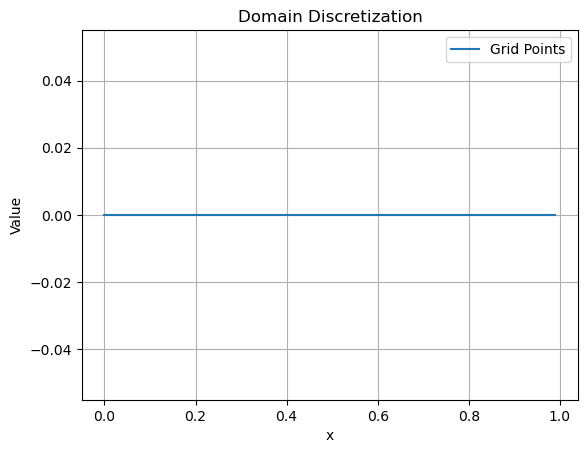

In [194]:
L = 1.0 # Length of the domain
N = 200 # Number of grid points

dx = L / (N + 1) # Grid spacing

print("Grid spacing (dx):", dx)

x = np.linspace(0, L - dx, N, endpoint=False)

alpha = 0.01 # Diffusion coefficient
r = 0.4 # Stability parameter

dt = r * dx**2 / alpha # Time step size
print("Time step size (dt):", dt)

u_0 = 1.0 # left boundary condition (dirichlet)
# right boundary condition (Neumann)
u_right = 0.0

nt = 500 # Number of time steps
T = nt * dt # Total simulation time
print("Total simulation time (T):", T)

plt.plot(x, np.zeros_like(x), label='Grid Points')
plt.title('Domain Discretization')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

## Initial Setup

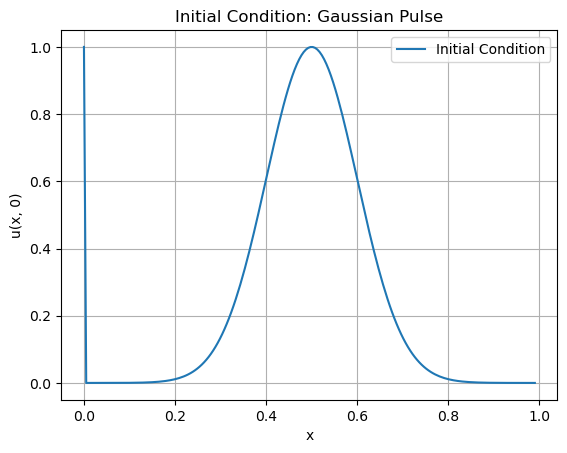

In [195]:
x0 = L / 2 # Initial position of the pulse
sigma = 0.1 # Width of the pulse
u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
u0[0] = u_0 # Set left boundary condition
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

## Apply Ghost Cells

In [196]:
def apply_ghost_cell(u, u_0, u_right):
    g = u_0 # Dirichlet boundary condition value at the left boundary

    # Left ghost cell value (Dirichlet boundary condition) : ghost_left = 2 * g - u[0]
    ghost_left = 2 * g - u[0] # g = 1.0 at the left boundary

    # Right ghost cell value (Neumann boundary condition) : ghost_right = u[-1]
    ghost_right = u[-1] # du/dx = 0 at the right boundary

    u = np.insert(u, 0, ghost_left) # Insert left ghost cell
    u = np.append(u, ghost_right) # Append right ghost cell

    return u

def remove_ghost_cells(u):
    return u[1:-1] # Remove ghost cells

## Solve the Explicit - FTCS

In [197]:
def diffusion_ftcs(u, r):
    u_left  = u[:-2] # u[i-1]
    u_right = u[2:]  # u[i+1]
    return u[1:-1] + r * (u_left - 2 * u[1:-1] + u_right) # FTCS scheme for diffusion

u = np.copy(u0) # Initialize the solution with the initial condition
u_history = [u.copy()] # Store the solution history for plotting
for n in range(nt):
    u = apply_ghost_cell(u, u_0, u_right)
    u = diffusion_ftcs(u, r) # Update the solution using the FTCS scheme
    u_history.append(u.copy()) # Store the solution at each time step

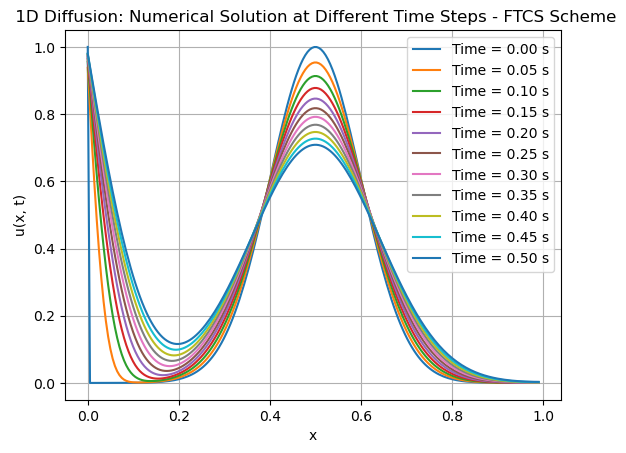

In [198]:
for n in range(0, nt + 1, 50):
    plt.plot(x, u_history[n], label=f'Time = {n*dt:.2f} s')
plt.title(' 1D Diffusion: Numerical Solution at Different Time Steps - FTCS Scheme')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

## Solve Implicit Scheme - BTCS

In [199]:
# BTCS scheme implementation - implicit method for diffusion equation (A*U = U_old)
def diffusion_btcs(u, r):
    A = np.zeros((N, N))
    np.fill_diagonal(A, 1 + 2 * r)
    np.fill_diagonal(A[1:], -r)
    np.fill_diagonal(A[:, 1:], -r)

    rhs = np.copy(u) # Right-hand side is the old solution

    # Dirichlet left: ghost_L = 2*g - u[0]
    rhs[0] += r * (2*u_0 - u[0])

    # Neumann right: ghost_R = u[-1] → A[-1,-1] = 1 + r
    A[-1, -1] = 1 + r

    u_new = np.linalg.solve(A, rhs) # Solve the linear system A * u_new = u
    return u_new

u = np.copy(u0) # Initialize the solution with the initial condition
u_history_btcs = [u.copy()] # Store the solution history for plotting
for n in range(nt):
    u = diffusion_btcs(u, r) # Update the solution using the BTCS scheme
    u_history_btcs.append(u.copy()) # Store the solution at each time step

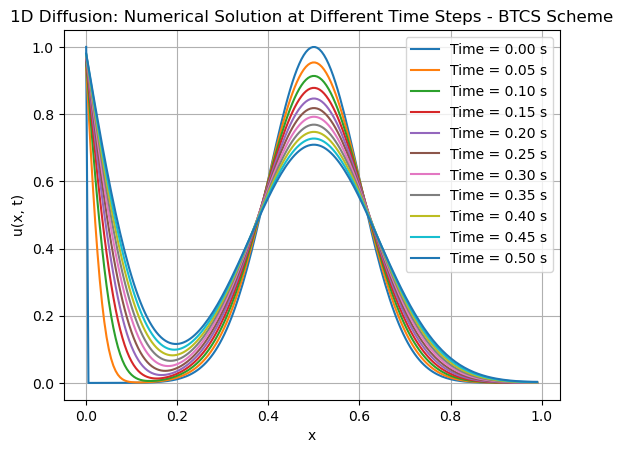

In [200]:
u_exact = np.exp(-((x - x0) ** 2) / (2 * (sigma**2 + 2 * alpha * T))) # Exact solution at time T

for n in range(0, nt + 1, 50):
    plt.plot(x, u_history_btcs[n], label=f'Time = {n*dt:.2f} s')
plt.title('1D Diffusion: Numerical Solution at Different Time Steps - BTCS Scheme')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()